<div style="text-align:left;">
    <span style="
        display:inline-block;
        background-color:#4169E1;
        color:white;
        padding:10px 20px;
        border-radius:8px;
        font-size:45px;
        font-weight:bold;
    ">
        Multi-layer Perceptron Model
    </span>
</div>

**Author:** Sarra Chouk 

**Student ID:** 60300372

**Project:** EHR Mortality Risk Prediction  

**Dataset:** MIMIC-IV

**Date:** April 4, 2026  

---

### **Objective**
To trains a deep multi-layer perceptron.

In [ ]:
from __future__ import annotations

import copy
import os
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=UserWarning)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed" / "master_table_model_ready.parquet").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find data/processed/master_table_model_ready.parquet from the current working directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "master_table_model_ready.parquet"

RANDOM_STATE = 42
TARGET_COL = "target"
GROUP_COL = "subject_id"
REFERENCE_COLS = ["subject_id", "hadm_id", "admittime"]

TEST_SIZE = 0.15
DEPLOYMENT_SIZE = 0.15
VAL_SHARE_OF_TRAIN = 0.10

HIDDEN_LAYER_SIZES = (128, 64, 32)
LEARNING_RATE_INIT = 5e-4
BATCH_SIZE = 4096
ALPHA = 1e-4
MAX_EPOCHS = 25
PATIENCE = 5
MIN_DELTA = 1e-4

np.random.seed(RANDOM_STATE)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")

Project root: /Users/sarrachouk/Desktop/ehr-mortality-prediction
Data path: /Users/sarrachouk/Desktop/ehr-mortality-prediction/data/processed/master_table_model_ready.parquet


In [ ]:
df = pd.read_parquet(DATA_PATH).copy()
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")

if df["admittime"].isna().any():
    raise ValueError("admittime contains invalid datetime values.")
if TARGET_COL not in df.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")

dataset_summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "patients": [df[GROUP_COL].nunique()],
        "columns": [df.shape[1]],
        "positive_rate": [df[TARGET_COL].mean()],
    }
).round(4)

missingness = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)

display(dataset_summary)
display(missingness.head(10).round(4))

,rows,patients,columns,positive_rate
0,546028,223452,53,0.0216


,missing_fraction
last_norm_lab,0.5449
bmi_last,0.4936
last_systolic,0.4425
last_pulse_pressure,0.4425
last_diastolic,0.4425
weight_last,0.4380
max_prev_drg_mortality,0.0842
avg_prev_drg_mortality,0.0842
max_prev_drg_severity,0.0842
avg_prev_drg_severity,0.0842


In [ ]:
def split_patients(df: pd.DataFrame) -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    patient_df = (
        df.groupby(GROUP_COL, as_index=False)[TARGET_COL]
        .max()
        .rename(columns={TARGET_COL: "patient_target"})
    )

    train_patients, holdout_patients = train_test_split(
        patient_df,
        test_size=TEST_SIZE + DEPLOYMENT_SIZE,
        stratify=patient_df["patient_target"],
        random_state=RANDOM_STATE,
    )

    test_patients, deployment_patients = train_test_split(
        holdout_patients,
        test_size=DEPLOYMENT_SIZE / (TEST_SIZE + DEPLOYMENT_SIZE),
        stratify=holdout_patients["patient_target"],
        random_state=RANDOM_STATE,
    )

    train_patients, validation_patients = train_test_split(
        train_patients,
        test_size=VAL_SHARE_OF_TRAIN,
        stratify=train_patients["patient_target"],
        random_state=RANDOM_STATE,
    )

    split_ids = {
        "train": set(train_patients[GROUP_COL]),
        "validation": set(validation_patients[GROUP_COL]),
        "test": set(test_patients[GROUP_COL]),
        "deployment": set(deployment_patients[GROUP_COL]),
    }

    overlaps = [
        split_ids["train"] & split_ids["validation"],
        split_ids["train"] & split_ids["test"],
        split_ids["train"] & split_ids["deployment"],
        split_ids["validation"] & split_ids["test"],
        split_ids["validation"] & split_ids["deployment"],
        split_ids["test"] & split_ids["deployment"],
    ]
    if any(overlaps):
        raise ValueError("Patient leakage detected across splits.")

    split_frames = {
        split_name: df[df[GROUP_COL].isin(patient_ids)].copy()
        for split_name, patient_ids in split_ids.items()
    }

    return split_frames, patient_df


def summarize_splits(split_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for split_name, frame in split_frames.items():
        rows.append(
            {
                "split": split_name,
                "rows": len(frame),
                "patients": frame[GROUP_COL].nunique(),
                "positive_rate": frame[TARGET_COL].mean(),
            }
        )
    return pd.DataFrame(rows).set_index("split").round(4)


def prepare_features(
    split_frames: dict[str, pd.DataFrame],
) -> tuple[list[str], SimpleImputer, StandardScaler, dict[str, np.ndarray], dict[str, np.ndarray]]:
    feature_cols = [
        col
        for col in split_frames["train"].columns
        if col not in REFERENCE_COLS + [TARGET_COL]
        and pd.api.types.is_numeric_dtype(split_frames["train"][col])
    ]

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X: dict[str, np.ndarray] = {}
    y: dict[str, np.ndarray] = {}

    train_imputed = imputer.fit_transform(split_frames["train"][feature_cols])
    X["train"] = scaler.fit_transform(train_imputed).astype("float32")
    y["train"] = split_frames["train"][TARGET_COL].astype("int8").to_numpy()

    for split_name in ["validation", "test", "deployment"]:
        split_imputed = imputer.transform(split_frames[split_name][feature_cols])
        X[split_name] = scaler.transform(split_imputed).astype("float32")
        y[split_name] = split_frames[split_name][TARGET_COL].astype("int8").to_numpy()

    for split_name, values in X.items():
        if np.isnan(values).any():
            raise ValueError(f"NaNs remained in {split_name} after preprocessing.")

    return feature_cols, imputer, scaler, X, y


def select_best_f1_threshold(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    if len(thresholds) == 0:
        return 0.5
    f1_scores = 2 * precision[1:] * recall[1:] / np.clip(precision[1:] + recall[1:], 1e-12, None)
    best_idx = int(np.nanargmax(f1_scores))
    return float(thresholds[best_idx])


def evaluate_ranking_metrics(y_true: np.ndarray, y_proba: np.ndarray) -> dict[str, float]:
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1]),
    }


def evaluate_classification_metrics(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
) -> dict[str, float]:
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "predicted_positive_rate": y_pred.mean(),
    }


def train_mlp_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
) -> tuple[MLPClassifier, pd.DataFrame]:
    model = MLPClassifier(
        hidden_layer_sizes=HIDDEN_LAYER_SIZES,
        activation="relu",
        solver="adam",
        alpha=ALPHA,
        batch_size=BATCH_SIZE,
        learning_rate_init=LEARNING_RATE_INIT,
        max_iter=1,
        shuffle=True,
        random_state=RANDOM_STATE,
        warm_start=True,
    )

    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
    classes = np.array([0, 1], dtype=np.int64)

    history = []
    best_model = None
    best_val_pr_auc = -np.inf
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.partial_fit(X_train, y_train, classes=classes, sample_weight=sample_weight)

        val_proba = model.predict_proba(X_val)[:, 1]
        val_pr_auc = average_precision_score(y_val, val_proba)
        val_roc_auc = roc_auc_score(y_val, val_proba)

        history.append(
            {
                "epoch": epoch,
                "train_loss": model.loss_,
                "val_pr_auc": val_pr_auc,
                "val_roc_auc": val_roc_auc,
            }
        )

        print(
            f"Epoch {epoch:02d} | train_loss={model.loss_:.5f} | "
            f"val_pr_auc={val_pr_auc:.5f} | val_roc_auc={val_roc_auc:.5f}"
        )

        if val_pr_auc > best_val_pr_auc + MIN_DELTA:
            best_val_pr_auc = val_pr_auc
            best_model = copy.deepcopy(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping triggered after epoch {epoch}.")
                break

    history_df = pd.DataFrame(history)
    return (best_model or model), history_df


def plot_training_history(history_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(history_df["epoch"], history_df["val_pr_auc"], marker="o", label="Validation PR-AUC")
    axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], marker="o", label="Validation ROC-AUC")
    axes[1].set_title("Validation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_split_curves(y_true: np.ndarray, y_proba: np.ndarray, split_name: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=axes[0])
    axes[0].set_title(f"{split_name} Precision-Recall Curve")

    RocCurveDisplay.from_predictions(y_true, y_proba, ax=axes[1])
    axes[1].set_title(f"{split_name} ROC Curve")

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true: np.ndarray, y_proba: np.ndarray, threshold: float, split_name: str) -> None:
    y_pred = (y_proba >= threshold).astype(int)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)
    ax.set_title(f"{split_name} Confusion Matrix @ threshold={threshold:.3f}")
    plt.tight_layout()
    plt.show()

In [ ]:
split_frames, patient_df = split_patients(df)
display(summarize_splits(split_frames))

feature_cols, imputer, scaler, X, y = prepare_features(split_frames)
class_ratio = (y["train"] == 0).sum() / max((y["train"] == 1).sum(), 1)

print(f"Using {len(feature_cols)} numeric features.")
print(f"Approximate negative-to-positive ratio in train: {class_ratio:.2f}:1")

shape_summary = pd.Series({split_name: values.shape for split_name, values in X.items()}, name="shape")
display(shape_summary)

,rows,patients,positive_rate
split,,,
train,343106,140774,0.0217
validation,37355,15642,0.0221
test,83356,33518,0.0212
deployment,82211,33518,0.0215


Using 49 numeric features.
Approximate negative-to-positive ratio in train: 45.15:1


train         (343106, 49)
validation     (37355, 49)
test           (83356, 49)
deployment     (82211, 49)
Name: shape, dtype: object

## Train The Deep MLP

The model below is a three-hidden-layer neural network trained with Adam, median imputation fit on training data only, standardized features, class-balanced sample weights, and early stopping on validation PR-AUC.

Epoch 01 | train_loss=0.56508 | val_pr_auc=0.12979 | val_roc_auc=0.83443
Epoch 02 | train_loss=0.48824 | val_pr_auc=0.13676 | val_roc_auc=0.84361
Epoch 03 | train_loss=0.47426 | val_pr_auc=0.14504 | val_roc_auc=0.84774
Epoch 04 | train_loss=0.46731 | val_pr_auc=0.15044 | val_roc_auc=0.84994
Epoch 05 | train_loss=0.46228 | val_pr_auc=0.15411 | val_roc_auc=0.85109
Epoch 06 | train_loss=0.45816 | val_pr_auc=0.15699 | val_roc_auc=0.85198
Epoch 07 | train_loss=0.45460 | val_pr_auc=0.15781 | val_roc_auc=0.85244
Epoch 08 | train_loss=0.45137 | val_pr_auc=0.15951 | val_roc_auc=0.85310
Epoch 09 | train_loss=0.44820 | val_pr_auc=0.15961 | val_roc_auc=0.85339
Epoch 10 | train_loss=0.44514 | val_pr_auc=0.16002 | val_roc_auc=0.85347
Epoch 11 | train_loss=0.44221 | val_pr_auc=0.16058 | val_roc_auc=0.85343
Epoch 12 | train_loss=0.43938 | val_pr_auc=0.15970 | val_roc_auc=0.85345
Epoch 13 | train_loss=0.43653 | val_pr_auc=0.15955 | val_roc_auc=0.85313
Epoch 14 | train_loss=0.43374 | val_pr_auc=0.15917 

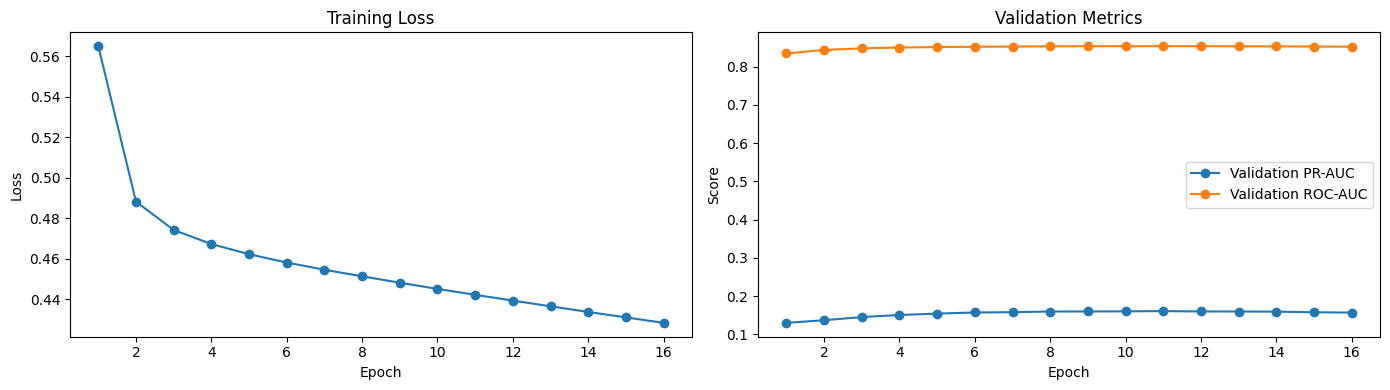

,epoch,train_loss,val_pr_auc,val_roc_auc
0,1,0.5651,0.1298,0.8344
1,2,0.4882,0.1368,0.8436
2,3,0.4743,0.1450,0.8477
3,4,0.4673,0.1504,0.8499
4,5,0.4623,0.1541,0.8511
5,6,0.4582,0.1570,0.8520
6,7,0.4546,0.1578,0.8524
7,8,0.4514,0.1595,0.8531
8,9,0.4482,0.1596,0.8534
9,10,0.4451,0.1600,0.8535


In [5]:
model, history_df = train_mlp_model(
    X_train=X["train"],
    y_train=y["train"],
    X_val=X["validation"],
    y_val=y["validation"],
)

plot_training_history(history_df)
display(history_df.round(4))

In [6]:
probabilities = {
    split_name: model.predict_proba(X[split_name])[:, 1]
    for split_name in ["validation", "test", "deployment"]
}

best_threshold = select_best_f1_threshold(y["validation"], probabilities["validation"])
print(f"Best validation threshold by F1: {best_threshold:.4f}")

ranking_results = []
threshold_results = []

for split_name, split_proba in probabilities.items():
    ranking_results.append(
        {
            "split": split_name,
            **evaluate_ranking_metrics(y[split_name], split_proba),
        }
    )

    for strategy_name, threshold in {
        "default_0.50": 0.50,
        "validation_best_f1": best_threshold,
    }.items():
        threshold_results.append(
            {
                "split": split_name,
                "threshold_strategy": strategy_name,
                "threshold": threshold,
                **evaluate_classification_metrics(y[split_name], split_proba, threshold),
            }
        )

ranking_df = pd.DataFrame(ranking_results).set_index("split").round(4)
threshold_df = (
    pd.DataFrame(threshold_results)
    .sort_values(["threshold_strategy", "split"])
    .reset_index(drop=True)
    .round(4)
)

display(ranking_df)
display(threshold_df)

Best validation threshold by F1: 0.8767


,roc_auc,pr_auc,brier_score,log_loss
split,,,,
validation,0.8534,0.1606,0.1618,0.4679
test,0.8535,0.1332,0.1629,0.4717
deployment,0.8548,0.1413,0.1603,0.4647


,split,threshold_strategy,threshold,accuracy,precision,recall,f1,predicted_positive_rate
0,deployment,default_0.50,0.5000,0.7439,0.0652,0.8171,0.1208,0.2698
1,test,default_0.50,0.5000,0.7396,0.0623,0.8017,0.1156,0.2732
2,validation,default_0.50,0.5000,0.7422,0.0662,0.8136,0.1225,0.2717
3,deployment,validation_best_f1,0.8767,0.9636,0.1851,0.2027,0.1935,0.0236
4,test,validation_best_f1,0.8767,0.9633,0.1899,0.2232,0.2052,0.0250
5,validation,validation_best_f1,0.8767,0.9652,0.2272,0.2385,0.2327,0.0232


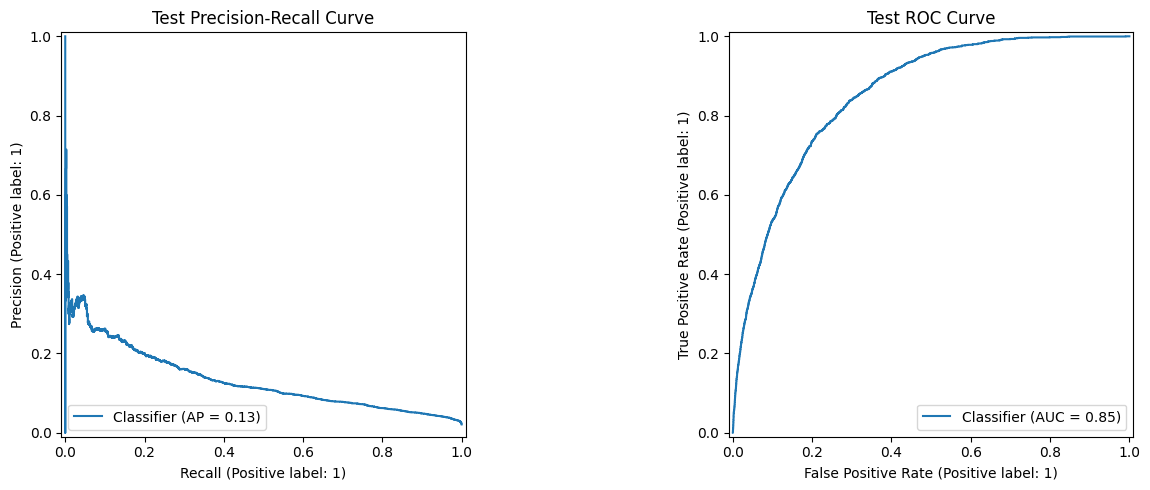

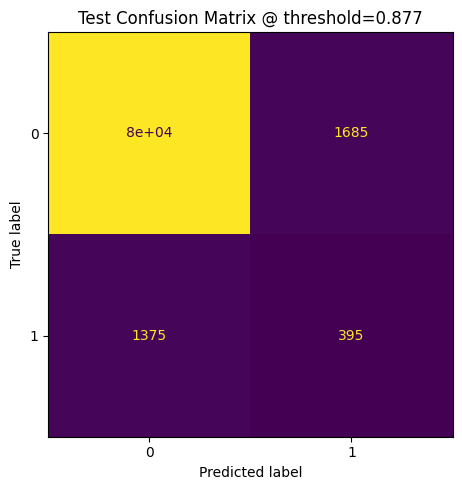

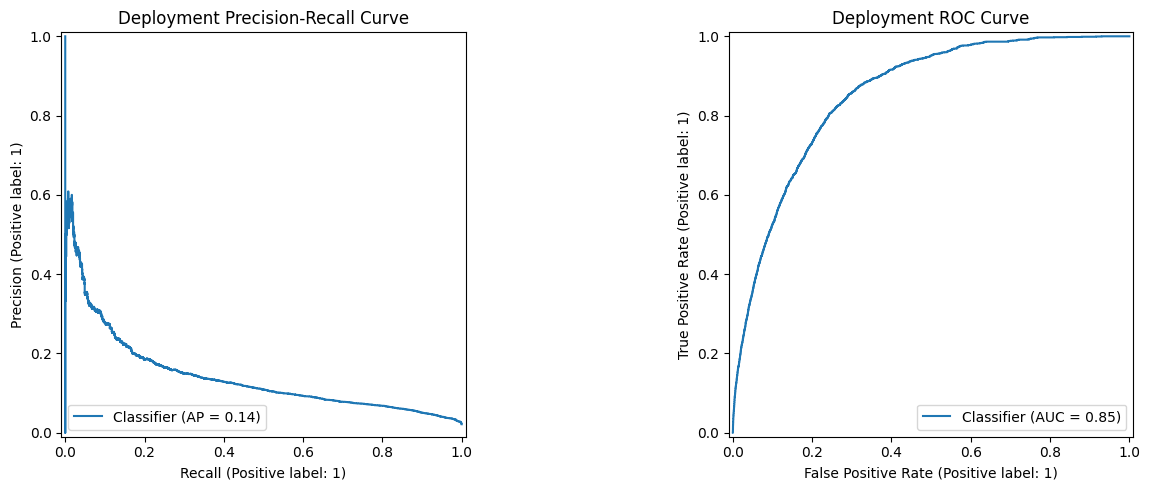

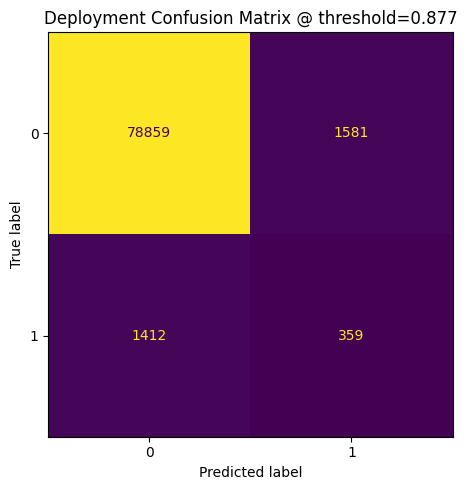

In [7]:
for split_name in ["test", "deployment"]:
    plot_split_curves(y[split_name], probabilities[split_name], split_name.title())
    plot_confusion(y[split_name], probabilities[split_name], best_threshold, split_name.title())

### Notebook Outputs

- `model`: trained deep MLP classifier
- `feature_cols`: ordered feature list used by the model
- `imputer`: fitted median imputer
- `scaler`: fitted standard scaler
- `probabilities`: predicted probabilities for validation, test, and deployment splits
- `ranking_df`: threshold-free metrics table
- `threshold_df`: threshold-dependent metrics table